# 03 — Explainable Recommendations (Fase 3C)

Cada recomendación responde **¿por qué?** combinando **SHAP** (modelo de deterioro), **rule trace** y **feature attribution**.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

CD = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(CD / "src"))
from predia_cdss import config
DS, MET, FIG, RUL, DASH = CD/"datasets", CD/"metrics", CD/"figures", CD/"rules", CD/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)
print("Entorno listo:", CD)


Entorno listo: /home/wowo/Descargas/predia/ml-research/clinical_decision_support


## Factores globales de deterioro (SHAP)

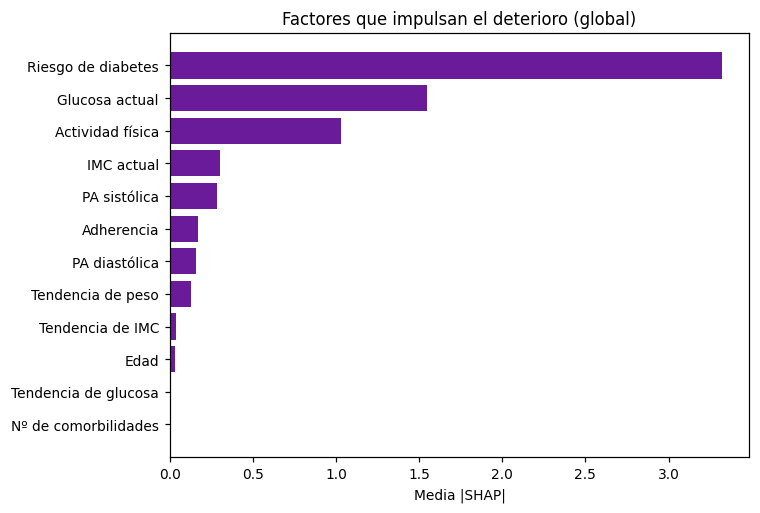

,feature,label,mean_abs_shap
0,riesgo_current,Riesgo de diabetes,3.3203
1,glucosa_current,Glucosa actual,1.5480
2,actividad_current,Actividad física,1.0287
3,imc_current,IMC actual,0.3000
4,pas_current,PA sistólica,0.2856
5,adherencia,Adherencia,0.1683
6,pad_current,PA diastólica,0.1559
7,peso_slope_m,Tendencia de peso,0.1258
8,imc_slope_m,Tendencia de IMC,0.0404
9,age,Edad,0.0301


In [2]:
show(FIG/'explain'/'shap_global.png')
pd.read_csv(MET/'shap_global.csv')

## Explicación de un paciente (¿por qué?)

In [3]:
recs = load(DS/'recommendations.json')
ex = max(recs, key=lambda r: r['priority']['score'])
print('Paciente', ex['patient_id'], '· prioridad', ex['priority']['score'],
      f"({ex['priority']['band']})")
print('\n¿Por qué?')
for b in ex['why']: print('  •', b)
print('\nFactores de riesgo (SHAP+):')
for f in ex['risk_factors']: print('  ', f['label'], '=', f['value'], f"(SHAP {f['shap']})")

Paciente 135 · prioridad 87.4 (Crítica)

¿Por qué?
  • Riesgo de diabetes = 1.0 (aumenta el riesgo)
  • Glucosa actual = 255.3 (aumenta el riesgo)
  • Actividad física = 59.31 (aumenta el riesgo)
  • PA sistólica = 166.62 (aumenta el riesgo)
  • [R04] Glucosa en rango muy alto: revisar tratamiento y reconfirmar medición
  • [R05] Presión arterial en rango de crisis
  • [R01] Glucosa e IMC elevados de forma simultánea
  • [R02] Presión arterial elevada en las últimas 3 consultas → seguimiento prioritario
  • [R06] Adherencia por debajo del umbral con medicación activa
  • [R07] Clinical Evolution Score bajo: deterioro de la evolución
  • [R11] Dos o más comorbilidades con riesgo elevado

Factores de riesgo (SHAP+):
   Riesgo de diabetes = 1.0 (SHAP 3.132)
   Glucosa actual = 255.3 (SHAP 1.546)
   Actividad física = 59.31 (SHAP 1.155)
   PA sistólica = 166.62 (SHAP 0.325)


### Conclusión 3C
La explicación es doble: **estadística** (SHAP, qué features empujan el riesgo) y **lógica** (qué reglas dispararon) — sin cajas negras.